# ECE1508 Tutorial 3:
## Generative vs. Discriminative Learning

# 1. Motivation

Suppose we want to classify an input \(x\) into a label \(y\).

For example:

- image $\rightarrow$ class label
- sentence $\rightarrow$ sentiment
- molecule $\rightarrow$ active/inactive
- medical record $\rightarrow$ diagnosis

There are two broad strategies:

---

## Discriminative learning

A **discriminative model** directly learns the decision rule:

$
p(y \mid x)
$

or simply a function

$
f_\theta(x) \rightarrow y.
$

Examples:

- Logistic regression
- SVM
- Standard neural network classifiers
- BERT-style text classifiers
- Vision Transformers trained for classification

The model asks: Given this input, what is the label?

---

## Generative learning

A **generative model** learns how the data is generated.

A common form is:

$
p(x,y) = p(x \mid y)p(y).
$

Then classification is done using Bayes' rule:

$
p(y \mid x) = \frac{p(x \mid y)p(y)}{p(x)}.
$

The model asks: What does the data look like under each class?

Examples:

- Gaussian naive Bayes
- Gaussian mixture models
- Hidden Markov models
- Latent Dirichlet allocation
- Variational autoencoders
- Autoregressive language models
- Diffusion models

---

## Important distinction

A discriminative model usually only gives labels.

A generative model can often do more:

- classify
- sample new data
- estimate likelihoods
- handle missing data
- detect out-of-distribution inputs
- support semi-supervised learning

# 2. Setup

We will use a simple 2D dataset so that we can visualize everything.

The dataset has two classes. Each class is generated from a Gaussian distribution.

This is intentionally simple: it lets us clearly see what discriminative and generative models are learning.

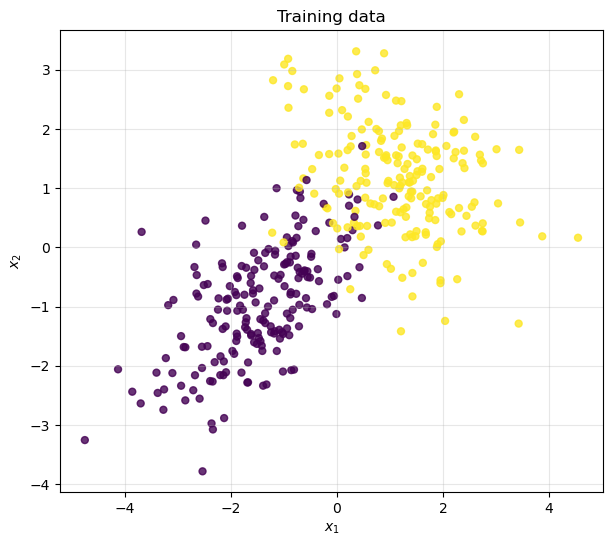

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, log_loss

np.random.seed(42)

def make_gaussian_data(n_per_class=300):
    mean0 = np.array([-1.5, -1.0])
    mean1 = np.array([1.2, 1.0])

    cov0 = np.array([[1.0, 0.6],
                     [0.6, 1.0]])

    cov1 = np.array([[1.0, -0.4],
                     [-0.4, 1.0]])

    X0 = np.random.multivariate_normal(mean0, cov0, size=n_per_class)
    X1 = np.random.multivariate_normal(mean1, cov1, size=n_per_class)

    X = np.vstack([X0, X1])
    y = np.array([0] * n_per_class + [1] * n_per_class)

    return X, y

X, y = make_gaussian_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y
)

plt.figure(figsize=(7, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, alpha=0.8)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Training data")
plt.grid(alpha=0.3)
plt.show()

# 3. Discriminative learning

We first train logistic regression.

Logistic regression directly models:

$
p_\theta(y = 1 \mid x) = \sigma(w^\top x + b).
$

It does **not** model how the data \(x\) was generated.

It only learns a boundary that separates the classes.

In [2]:
disc_model = LogisticRegression()
disc_model.fit(X_train, y_train)

disc_probs = disc_model.predict_proba(X_test)
disc_preds = disc_model.predict(X_test)

disc_acc = accuracy_score(y_test, disc_preds)
disc_nll = log_loss(y_test, disc_probs)

print(f"Discriminative model accuracy: {disc_acc:.3f}")
print(f"Discriminative model negative log-likelihood: {disc_nll:.3f}")

Discriminative model accuracy: 0.952
Discriminative model negative log-likelihood: 0.125


## Visualize the discriminative decision boundary

The decision boundary is the set of points where:

$
p(y=1 \mid x) = 0.5.
$

For logistic regression, this boundary is linear.

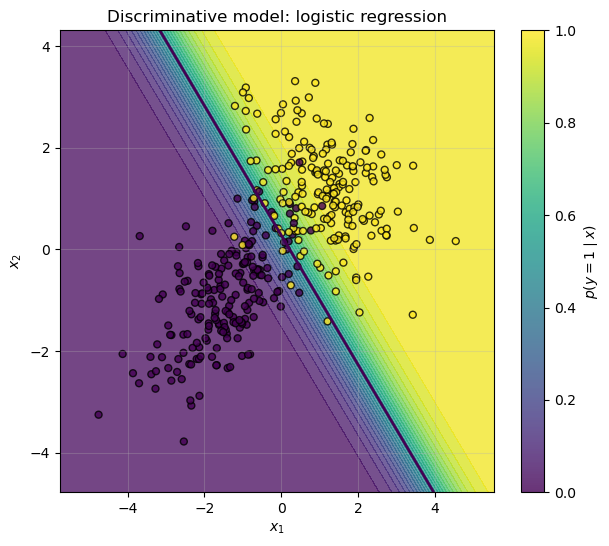

In [3]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, probs, levels=30, alpha=0.75)
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor="k", alpha=0.8)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.colorbar(label="$p(y=1 \\mid x)$")
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(
    disc_model,
    X_train,
    y_train,
    "Discriminative model: logistic regression"
)

# 4. Generative learning

Now we train a generative classifier.

We model:

$
p(x,y) = p(x \mid y)p(y).
$

For each class \(y\), Gaussian naive Bayes assumes:

$
p(x \mid y) = \prod_j p(x_j \mid y).
$

That means each feature is conditionally independent given the class.

This assumption is often false, but the model is still useful for understanding the generative idea.

---

## Classification with Bayes' rule

Once we have $p(x \mid y)$ and $p(y)$, we classify using:

$
p(y \mid x) =
\frac{p(x \mid y)p(y)}
{\sum_{y'} p(x \mid y')p(y')}.
$

In [4]:
gen_model = GaussianNB()
gen_model.fit(X_train, y_train)

gen_probs = gen_model.predict_proba(X_test)
gen_preds = gen_model.predict(X_test)

gen_acc = accuracy_score(y_test, gen_preds)
gen_nll = log_loss(y_test, gen_probs)

print(f"Generative classifier accuracy: {gen_acc:.3f}")
print(f"Generative classifier negative log-likelihood: {gen_nll:.3f}")

Generative classifier accuracy: 0.948
Generative classifier negative log-likelihood: 0.131


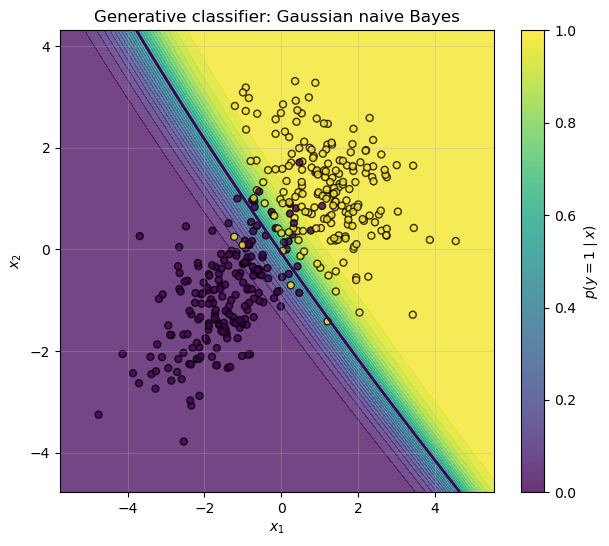

In [5]:
plot_decision_boundary(
    gen_model,
    X_train,
    y_train,
    "Generative classifier: Gaussian naive Bayes"
)

# 5. What did the generative model learn?

Unlike logistic regression, Gaussian naive Bayes estimates class-conditional data distributions.

For each class, it learns:

- a class prior \(p(y)\)
- a mean for each feature
- a variance for each feature

Let us inspect those parameters.

In [6]:
print("Class priors p(y):")
print(gen_model.class_prior_)

print("\nClass means:")
print(gen_model.theta_)

print("\nClass variances:")
print(gen_model.var_)

Class priors p(y):
[0.5 0.5]

Class means:
[[-1.46409705 -0.94320545]
 [ 1.15195379  1.15132104]]

Class variances:
[[0.99941651 0.93571864]
 [1.04921385 0.84652345]]


# 6. Sampling from the generative classifier

Because the generative model learned $(p(x \mid y))$, we can sample synthetic data.

This is the key extra ability of generative models.

The generated samples will not be perfect because Gaussian naive Bayes makes a simple independence assumption, but the idea is the same:

1. Choose a class $(y \sim p(y))$.
2. Sample $(x \sim p(x \mid y))$.

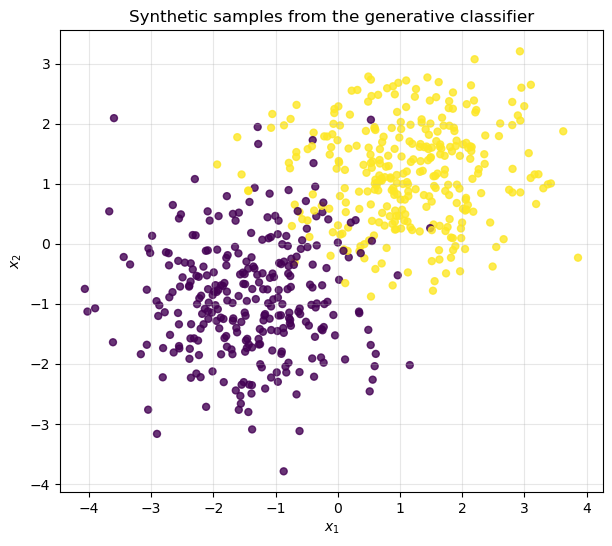

In [7]:
def sample_from_gaussian_nb(model, n_samples=300):
    class_priors = model.class_prior_
    classes = model.classes_

    sampled_y = np.random.choice(classes, size=n_samples, p=class_priors)

    sampled_X = np.zeros((n_samples, model.theta_.shape[1]))

    for i, cls in enumerate(sampled_y):
        cls_idx = np.where(classes == cls)[0][0]
        mean = model.theta_[cls_idx]
        std = np.sqrt(model.var_[cls_idx])
        sampled_X[i] = np.random.normal(loc=mean, scale=std)

    return sampled_X, sampled_y

X_sampled, y_sampled = sample_from_gaussian_nb(gen_model, n_samples=600)

plt.figure(figsize=(7, 6))
plt.scatter(X_sampled[:, 0], X_sampled[:, 1], c=y_sampled, s=25, alpha=0.8)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Synthetic samples from the generative classifier")
plt.grid(alpha=0.3)
plt.show()

# 7. Compare real and generated data

A good generative model should produce samples that resemble the real data distribution.

Here we compare real training data and generated data side by side.

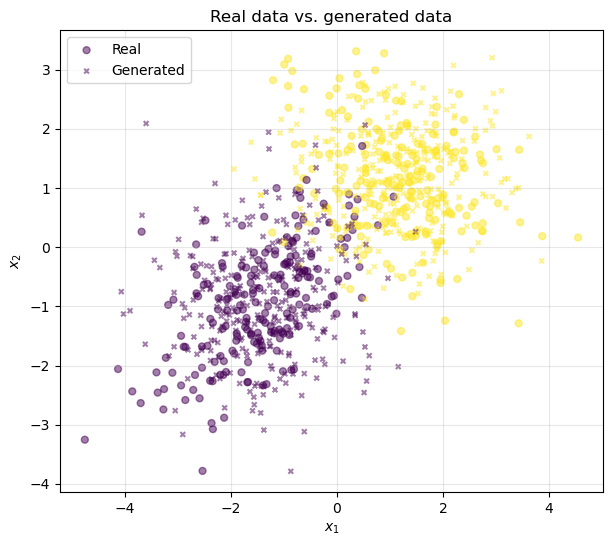

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, alpha=0.5, label="Real")
plt.scatter(X_sampled[:, 0], X_sampled[:, 1], c=y_sampled, s=12, marker="x", alpha=0.5, label="Generated")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Real data vs. generated data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Discriminative vs. generative: summary table

| Question | Discriminative model | Generative model |
|---|---|---|
| What does it model? | $p(y \mid x)$ | $p(x,y)$, often via $p(x \mid y)p(y)$ |
| Main goal | Predict labels | Model data generation |
| Can classify? | Yes | Yes, using Bayes' rule |
| Can generate new data? | Usually no | Yes |
| Example classical models | Logistic regression, SVM | Naive Bayes, GMM, HMM |
| Example deep models | Neural classifiers | VAE, GAN, diffusion, autoregressive LM |
| Strength | Often high predictive accuracy | Richer data modeling |
| Weakness | Does not explain/generate data | Harder density modeling or sampling |

# 9. Nonlinear case study: two moons

The Gaussian example above is friendly to both kinds of methods. The two-moons dataset is a useful stress test because each class bends around the other.

Here we compare:

- a simple discriminative linear classifier
- a more flexible discriminative classifier
- a simple generative Gaussian naive Bayes classifier
- a more flexible generative classifier that fits a Gaussian mixture model per class

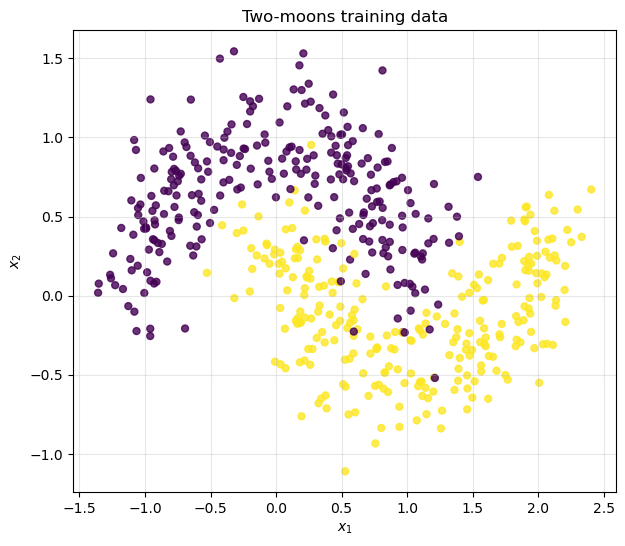

In [9]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=800, noise=0.22, random_state=42)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.35,
    random_state=42,
    stratify=y_moons
)

plt.figure(figsize=(7, 6))
plt.scatter(X_moons_train[:, 0], X_moons_train[:, 1], c=y_moons_train, s=25, alpha=0.8)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Two-moons training data")
plt.grid(alpha=0.3)
plt.show()


## Models to compare

The RBF-kernel SVM is still **discriminative** because it directly learns a rule for $p(y \mid x)$ or the class boundary.

The class-conditional GMM classifier is **generative** because it estimates a density $p(x \mid y)$ for each class, combines it with the prior $p(y)$, and then classifies using Bayes' rule.


In [10]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

class GMMGenerativeClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=8, covariance_type="full", random_state=42):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_log_prior_ = np.log(counts / counts.sum())
        self.models_ = {}

        for cls in self.classes_:
            class_model = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                random_state=self.random_state
            )
            class_model.fit(X[y == cls])
            self.models_[cls] = class_model

        return self

    def predict_proba(self, X):
        log_joint = np.column_stack([
            self.models_[cls].score_samples(X) + self.class_log_prior_[i]
            for i, cls in enumerate(self.classes_)
        ])
        stabilized = np.exp(log_joint - log_joint.max(axis=1, keepdims=True))
        return stabilized / stabilized.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

moon_model_specs = [
    (
        "Linear logistic regression",
        "discriminative",
        LogisticRegression(max_iter=1000)
    ),
    (
        "RBF-kernel SVM",
        "discriminative",
        make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", C=5.0, gamma=2.0, probability=True, random_state=42)
        )
    ),
    (
        "Gaussian naive Bayes",
        "generative",
        GaussianNB()
    ),
    (
        "Class-conditional GMM",
        "generative",
        GMMGenerativeClassifier(n_components=8, random_state=42)
    ),
]

moon_fitted_models = {}
moon_results = []

for name, family, model in moon_model_specs:
    model.fit(X_moons_train, y_moons_train)
    probs = model.predict_proba(X_moons_test)
    preds = model.predict(X_moons_test)

    moon_fitted_models[name] = model
    moon_results.append((
        name,
        family,
        accuracy_score(y_moons_test, preds),
        log_loss(y_moons_test, probs)
    ))

print(f"{'Model':28s} {'Family':16s} {'Accuracy':>9s} {'NLL':>9s}")
print("-" * 66)
for name, family, acc, nll in moon_results:
    print(f"{name:28s} {family:16s} {acc:9.3f} {nll:9.3f}")


Model                        Family            Accuracy       NLL
------------------------------------------------------------------
Linear logistic regression   discriminative       0.893     0.262
RBF-kernel SVM               discriminative       0.968     0.120
Gaussian naive Bayes         generative           0.896     0.254
Class-conditional GMM        generative           0.950     0.147


## Decision boundaries on two moons

The linear models can only draw simple boundaries. The flexible discriminative SVM learns the nonlinear boundary directly. The flexible generative GMM gets a nonlinear boundary indirectly by modeling each class density first.


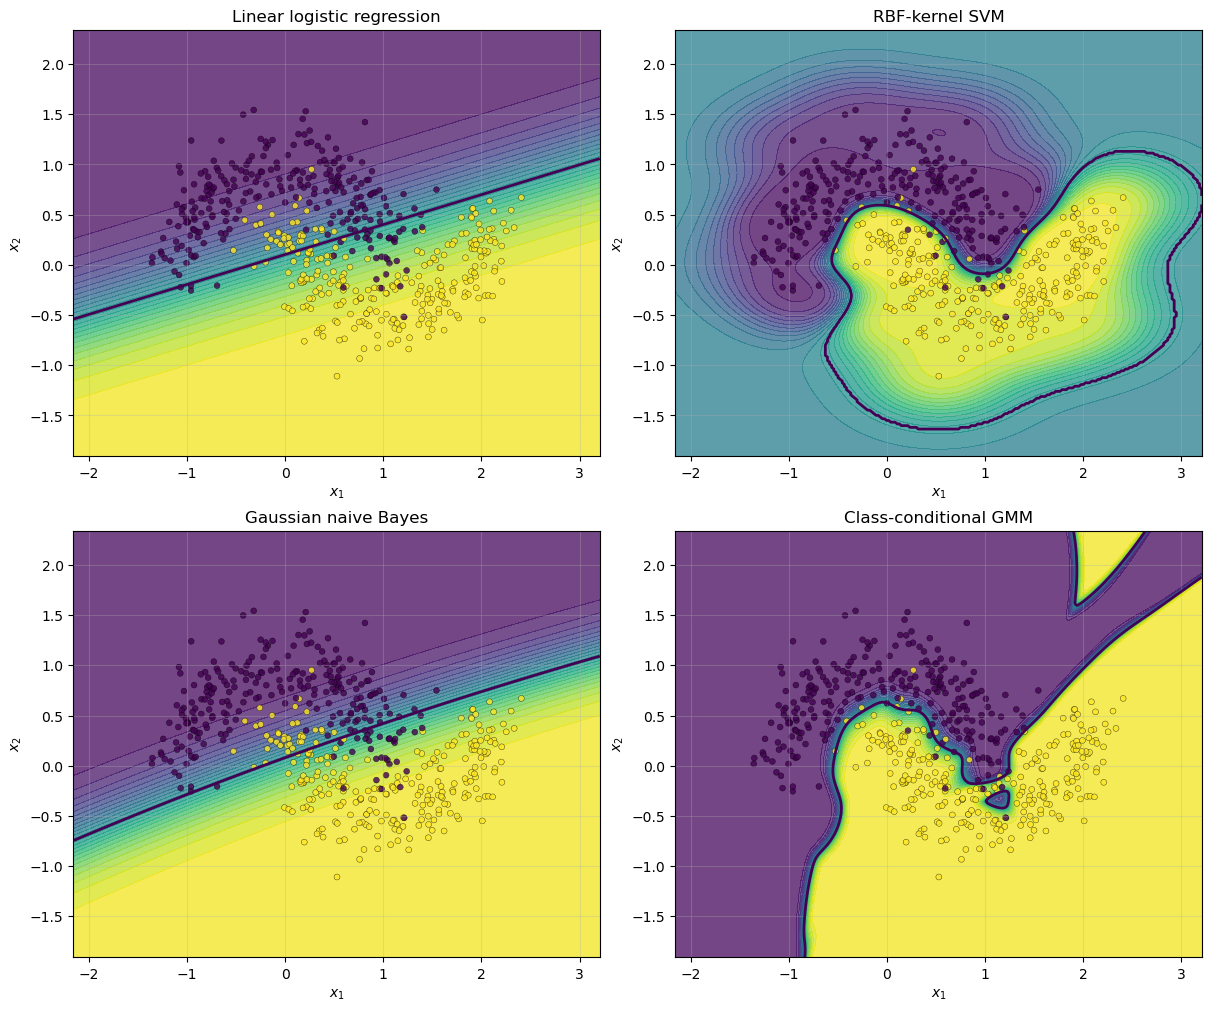

In [11]:
def plot_decision_boundary_on_axis(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=30, alpha=0.75)
    ax.contour(xx, yy, probs, levels=[0.5], linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k", linewidth=0.3, alpha=0.8)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

for ax, (name, model) in zip(axes.ravel(), moon_fitted_models.items()):
    plot_decision_boundary_on_axis(model, X_moons_train, y_moons_train, name, ax)

plt.show()


## What can the generative models sample?

The discriminative models above do not define a distribution over inputs, so there is no direct way to sample new two-moons points from them.

The generative models do define $p(x \mid y)$, so we can sample from them. This makes their assumptions visible: Gaussian naive Bayes produces elliptical clouds, while the class-conditional GMM can approximate the curved moons with several local Gaussian pieces.


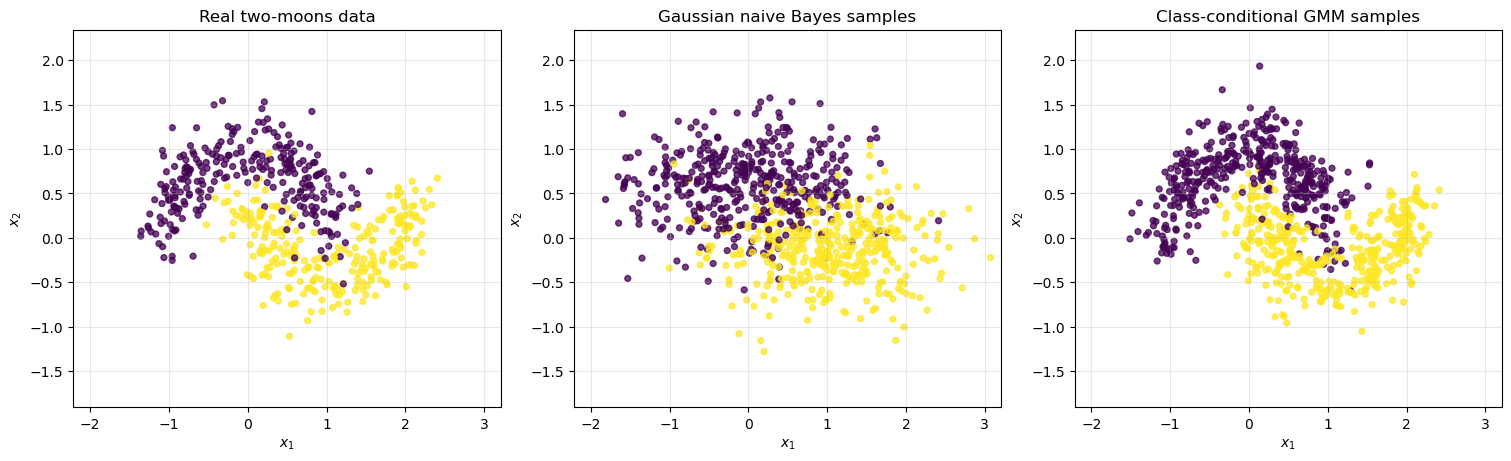

In [12]:
def sample_from_gmm_classifier(model, n_samples=800, random_state=42):
    rng = np.random.default_rng(random_state)
    class_priors = np.exp(model.class_log_prior_)
    sampled_y = rng.choice(model.classes_, size=n_samples, p=class_priors)
    sampled_X = np.zeros((n_samples, X_moons.shape[1]))

    for cls in model.classes_:
        mask = sampled_y == cls
        if mask.sum() > 0:
            sampled_X[mask], _ = model.models_[cls].sample(mask.sum())

    return sampled_X, sampled_y

X_moons_nb_sampled, y_moons_nb_sampled = sample_from_gaussian_nb(
    moon_fitted_models["Gaussian naive Bayes"],
    n_samples=800
)
X_moons_gmm_sampled, y_moons_gmm_sampled = sample_from_gmm_classifier(
    moon_fitted_models["Class-conditional GMM"],
    n_samples=800,
    random_state=42
)

sample_panels = [
    ("Real two-moons data", X_moons_train, y_moons_train),
    ("Gaussian naive Bayes samples", X_moons_nb_sampled, y_moons_nb_sampled),
    ("Class-conditional GMM samples", X_moons_gmm_sampled, y_moons_gmm_sampled),
]

x_min, x_max = X_moons[:, 0].min() - 0.8, X_moons[:, 0].max() + 0.8
y_min, y_max = X_moons[:, 1].min() - 0.8, X_moons[:, 1].max() + 0.8

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, (title, X_panel, y_panel) in zip(axes, sample_panels):
    ax.scatter(X_panel[:, 0], X_panel[:, 1], c=y_panel, s=18, alpha=0.75)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.show()


# 10. Connection to deep generative models

In deep generative modeling, we often care about learning a complex data distribution:

$
p_\theta(x).
$

For example:

- images
- audio
- molecules
- text
- videos
- trajectories

Different deep generative model families learn or approximate this distribution in different ways.

---

## Autoregressive models

Autoregressive models factorize:

$
p_\theta(x) = \prod_{t=1}^T p_\theta(x_t \mid x_{<t}).
$

Examples:

- GPT-style language models
- PixelCNN
- WaveNet

They generate one token, pixel, or sample at a time.

---

## Variational autoencoders

VAEs introduce latent variables \(z\):

$
p_\theta(x,z) = p_\theta(x \mid z)p(z).
$

They learn a latent representation and optimize a variational lower bound.

---

## GANs

GANs do not usually provide an explicit likelihood.

They learn a generator:

$
x = G_\theta(z)
$

by training against a discriminator.

The discriminator tries to distinguish real from fake samples, while the generator tries to fool it.

---

## Diffusion models

Diffusion models learn to reverse a noising process.

They gradually transform noise into data.

They are generative because they learn a process that can sample from the data distribution.
